# Random Numbers

- A random number is a number, chosen by chance from a distribution.

- Python provides a lot of modules, which deal with random numbers.

    - `random` module of python standard library.
    - `random` module of `numpy`.
    - `stats` module of `scipy`.


In [2]:
import numpy as np
from scipy import stats

## Numpy's Random Module

- `random` module of `numpy` has utilities, which generate arrays of random numbers.

- E.g.: `rand` function generates uniformly distributed numbers from range **[0, 1)**.

- `rand` function with no arguments generate a single random value. By passing arguments, it generates a random array of specified size.

In [3]:
print(np.random.rand())

# generates a 2*3 array
print(np.random.rand(2,3))

0.34184876571011513
[[0.4985388  0.55173204 0.57741996]
 [0.68917719 0.01966785 0.19794508]]


### Random Sampling

- *In statistics, you select items randomly from a population, either with or without a replacement.*

- `choice` method is used to select random sample from the population data

In [4]:
np.random.choice([11, 22, 33, 44, 55], 3, replace=False)

array([11, 33, 55])

### Random Seeding

**Seed** is an important concept when it comes to reproducibility. If you are working with random numbers and you would want to peers to validate your results, i.e., they should also get the same random sequence as you did, you can set the seed to a particular value and send the seed value to your peers.

- `seed` is a number that sets the initial state of random number generator.

- Setting a seed, helps in generating the same sequence of random numbers, repeatedly.

- `seed` method of a random module can be used to set a seed as shown in below example.



In [5]:
np.random.seed(100)
print(np.random.rand())

np.random.seed(100)
print(np.random.rand())

0.5434049417909654
0.5434049417909654


### Random Variables

- In probability theory, the set of all possible outcomes of a random experiment is known as **sample space**.

- Probabilities of all outcomes of the experiment define the *probability distribution*.

- A **random variable** is a variable that takes real numbers or integers and map each value to one of the outcomes of sample space.

- E.g.: In an experiment of tossing a coin, the sample space is **{'Head', 'Tail'}** and a possible random variable takes the value 0 for head and 1 for the tail.

### Probability Distributions

- There are two types of probability distributions namely **discrete** and **continuous** that take integer and real values, respectively.

- `scipy.stats` module provides classes that represent random variables, corresponding to a large number of probability distributions.

    - The class `norm` represents normal continuous random variable.
    - The class `binom` represents binomial discrete random variable.

### Random Distributions

- `scipy.stats` module provide a lot of methods for created discrete and continuous random variables.

- Commonly used methods are described below.

    - `pdf / pmf` : Probability distribution function (continuous) or probability mass function (discrete).
    - `cdf` : Cumulative distribution function.
    - `sf` : Survival function (1 – cdf).
    - `rvs` : Creating random samples from a distribution.

In [6]:
# Normal Distribution.
mean = 1
std = 2.5
distribution = stats.norm(mean, std)
xvalues = np.array([-1, 0, 1, 2, 3])
print(f'PDF: {distribution.pdf(xvalues)}')
print(f'CDF: {distribution.cdf(xvalues)}')
print(f'Sample distributions: {distribution.rvs(20)}')
print(f'Mean of Sample distributions: {np.mean(distribution.rvs(20))}')
print(f'Stadard Deviation of Sample distributions: {np.std(distribution.rvs(20))}')

PDF: [0.11587662 0.14730806 0.15957691 0.14730806 0.11587662]
CDF: [0.2118554  0.34457826 0.5        0.65542174 0.7881446 ]
Sample distributions: [-0.40409689 -3.12269376  1.88668613 -0.96516083  0.42031951  1.5199392
  3.33951992  1.44894578 -0.44290376 -0.33343178  0.4364947   0.21270166
  2.05749196 -0.09706702 -0.25353365 -3.14675709 -1.51894324 -0.27183608
  2.95372105 -0.63595258]
Mean of Sample distributions: 1.2700149730847436
Stadard Deviation of Sample distributions: 3.0170280238474727


### scipy.stats.norm

A normal continuous random variable. The location (`loc`) keyword specifies the mean. The scale (`scale`) keyword specifies the standard deviation.

| Methods      | Description |
| ----------- | ----------- |
| `rvs(loc=0, scale=1, size=1, random_state=None)` | Random variates. |
| `pdf(x, loc=0, scale=1)` | Probability density function. |
| `logpdf(x, loc=0, scale=1)` | Log of the probability density function. |
| `cdf(x, loc=0, scale=1)`| Cumulative distribution function. |
| `logcdf(x, loc=0, scale=1)`| Log of the cumulative distribution function. |
| `sf(x, loc=0, scale=1)` | Survival function (also defined as 1 - cdf, but sf is sometimes more accurate). |
| `ppf(q, loc=0, scale=1)` | Percent point function (inverse of cdf — percentiles). |
| `stats(loc=0, scale=1, moments=’mv’)` | Mean(‘m’), variance(‘v’), skew(‘s’), and/or kurtosis(‘k’). |
| `median(loc=0, scale=1)` | Median of the distribution. |
| `mean(loc=0, scale=1)` | Mean of the distribution. |
| `var(loc=0, scale=1)` | Variance of the distribution. |
| `std(loc=0, scale=1)` | Standard deviation of the distribution. |
| `interval(confidence, loc=0, scale=1)` | Confidence interval with equal areas around the median. |



#### Example

- Create a function **compute_absolute_difference()** that accepts three parameters: **mean**, **std**, and **seed**. Perform the following operations given below:

    - Create a normal distribution with input parameter: **mean** and **std**.

    - Set the random state with input **seed**, and create a random sample of **100** elements from the above defined distribution.

    - Compute the absolute difference between the sample mean and the distribution mean and return it.

- Test the function with **mean = 14.8**, **std = 2.5** and **seed = 1000** values.

In [7]:
from scipy.stats import norm

def compute_absolute_difference(mean, std, seed):

    # Create normal distribution.
    distribution = norm(mean, std)

    # Create random sample of 100 elements from the distribution.
    samples = distribution.rvs(size=100, random_state=seed)

    # Compute absolute difference of sample and distribution means.
    abs_diff_mean = np.abs(distribution.mean() - samples.mean())

    return abs_diff_mean

print(compute_absolute_difference(mean = 14.8, std = 2.5, seed = 1000))

0.14234901417494328


### scipy.stats.binom

A binomial discrete random variable. `binom` takes two parameters: `n` is number of trials, and `p` is the probability of success. 

| Methods | Description |
| ------- | ----------- |
| `rvs(n, p, loc=0, size=1, random_state=None)` | Random variates. |
| `pmf(k, n, p, loc=0)` | Probability mass function. |
| `cdf(k, n, p, loc=0)` | Cumulative distribution function. |
| `sf(k, n, p, loc=0)` | Survival function (also defined as 1 - cdf, but sf is sometimes more accurate). |
| `ppf(q, n, p, loc=0)` | Percent point function (inverse of cdf — percentiles). |
| `stats(n, p, loc=0, moments=’mv’)` | Mean(‘m’), variance(‘v’), skew(‘s’), and/or kurtosis(‘k’). |
| `median(n, p, loc=0)` | Median of the distribution. |
| `mean(n, p, loc=0)` | Mean of the distribution. |
| `var(n, p, loc=0)` | Variance of the distribution. |
| `std(n, p, loc=0)` | Standard deviation of the distribution. |
| `interval(confidence, n, p, loc=0)` | Confidence interval with equal areas around the median. |



#### Example

- In a factory, sample inspection is going on.
- Inspecting 10 items, there is chance of being defective item is **10%**.
- What is the probability of finding **2** defective items in the sample of 10?

In [8]:
from scipy.stats import binom

# Data from the above problem.
n = 10
p = 0.1
k = 2

# Generating Binomial Distribution.
dist = binom(n, p)

# Calculating probability of K = 2.
prob = dist.pmf(k)
print(f'The probability of finding 2 defective item: {prob * 100:.2f}%')

The probability of finding 2 defective item: 19.37%


#### Example

- Create a function **create_random_toss()** that accepts two parameters: **number_sample**, **random_state** where:
    
    - **number_sample**: Sample size.

    - **random_state**: Random state of the distribution.

- The above function performs the following operations:

    - Simulate a random experiment of tossing a coin of **number_sample** times, and determine the count of Heads and Tails returned.

    - Draw a sample of **number_sample** elements from a defined distribution. Assume that the values **0** and **1** represent **Heads** and **Tails** respectively.

    - Returns the number of Heads and Tails.

- Test the function with **number_sample = 9999** and **random_state = 101**.

In [9]:
from scipy.stats import binom

def create_random_toss(number_sample, random_state):
    # Generate a binomial distribution for tossing a coin.
    n = 1
    p = 0.5

    # Generating the Random Sample.
    rand_sample = binom.rvs(n, p, size = number_sample, random_state = random_state)

    # Counting the number of Tails (1s).
    tail_ct = rand_sample.sum()

    # Counting the number of Heads (0s).
    head_ct = (rand_sample == 0).sum()

    result = {
        'Heads': head_ct,
        'Tails': tail_ct
    }

    return result

for key, val in create_random_toss(number_sample=9999, random_state=101).items():
    print(f'Count of {key} - {val}')

Count of Heads - 4975
Count of Tails - 5024


### Plotting the Probability Distributions.

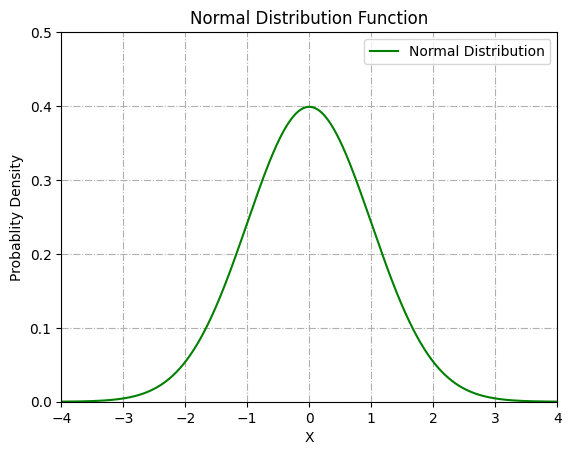

In [30]:
# Plotting Normal Distribution.

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# Generating normal distribution
x = np.linspace(-4, 4, 1000)
y = norm.pdf(x)

# Plotting
plt.title('Normal Distribution Function')
plt.xlabel('X')
plt.ylabel('Probablity Density')
plt.xlim(-4.0, 4.0)
plt.ylim(0.0, 0.5)

plt.plot(x, y, color = 'green', label = 'Normal Distribution')

plt.grid(linestyle = '-.')
plt.legend()
plt.show()

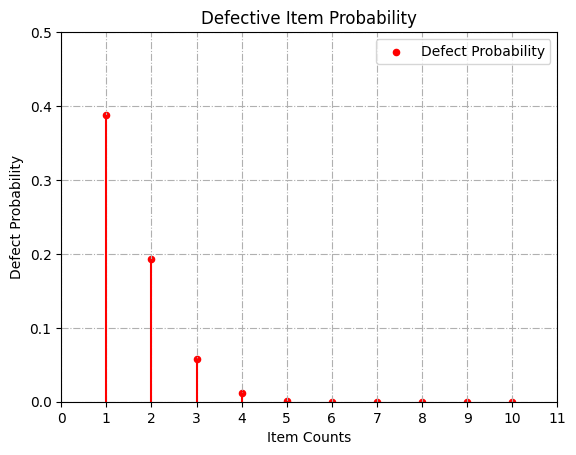

In [52]:
from scipy.stats import binom
import numpy as np
import matplotlib.pyplot as plt

# Data from the above problem.
n = 10
p = 0.1
k = np.linspace(1, 10, 10)

# Generating Binomial Distribution.
dist = binom(n, p)

# Plotting.
ax = plt.subplot()
ax.set(title='Defective Item Probability', xlabel='Item Counts', ylabel='Defect Probability',
       xlim = (1, 10), ylim = (0.0, 0.5), xticks = list(range(12)))
plt.scatter(k, dist.pmf(k), marker = 'o', c = ['red'], s = [20], label = 'Defect Probability')
plt.vlines(k, 0, dist.pmf(k), colors='red')
plt.legend()
plt.grid(linestyle = '-.')
